# Business Insights

This notebook examines the pharmaceutical sales dataset from a **commercial perspective** rather than a modelling perspective. The goal is to surface the business story behind the data — which molecules and brands are growing, how pricing varies across the portfolio, and where revenue is concentrated.

These insights complement the forecasting work in `01_01_eda.ipynb`, `02_model_comparison.ipynb`, and `04_04_lightgbm.ipynb` by providing the business context that would typically be shared with a non-technical stakeholder.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_excel('../data/test_data_working_students.xlsx').iloc[:4260].dropna()
df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))

print(f"Records: {len(df):,}  |  Period: {df['date'].min().strftime('%b %Y')} – {df['date'].max().strftime('%b %Y')}")
print(f"Molecules: {df['MoleculeName'].nunique()}  |  Brands: {df['TradeName'].nunique()}  |  SKUs: {df['ProductName'].nunique()}")

Records: 4,254  |  Period: Dec 2017 – Dec 2020
Molecules: 27  |  Brands: 68  |  SKUs: 154


## Year-on-Year Revenue Growth by Molecule

We compare total annual revenue per molecule across 2018, 2019, and 2020.  
This reveals which molecules are growing market share, which are stable, and which are declining —  
context that directly affects how confident we should be in a forward-looking forecast for each molecule.

In [2]:
# Use full years only (2018, 2019, 2020) — 2017 only has December
df_full_years = df[df['year'].isin([2018, 2019, 2020])].copy()

yoy = (df_full_years.groupby(['year', 'MoleculeName'])['Value']
       .sum()
       .reset_index()
       .pivot(index='MoleculeName', columns='year', values='Value')
       .fillna(0))

yoy.columns = [str(c) for c in yoy.columns]
yoy['growth_18_19'] = (yoy['2019'] - yoy['2018']) / yoy['2018'].replace(0, np.nan) * 100
yoy['growth_19_20'] = (yoy['2020'] - yoy['2019']) / yoy['2019'].replace(0, np.nan) * 100
yoy = yoy.sort_values('2020', ascending=False)

print("Top 10 molecules by 2020 revenue:")
display_cols = ['2018', '2019', '2020', 'growth_18_19', 'growth_19_20']
print(yoy[display_cols].head(10).to_string(
    formatters={
        '2018': '€{:>12,.0f}'.format,
        '2019': '€{:>12,.0f}'.format,
        '2020': '€{:>12,.0f}'.format,
        'growth_18_19': '{:>+.1f}%'.format,
        'growth_19_20': '{:>+.1f}%'.format,
    }
))

Top 10 molecules by 2020 revenue:
                      2018          2019          2020 growth_18_19 growth_19_20
MoleculeName                                                                    
molecule16   €  45,411,896 €  56,902,245 €  55,503,693       +25.3%        -2.5%
molecule5    €  43,692,006 €  53,475,607 €  55,482,536       +22.4%        +3.8%
molecule9    €  57,230,792 €  64,605,157 €  54,712,224       +12.9%       -15.3%
molecule22   €  15,521,415 €  15,470,745 €  15,292,692        -0.3%        -1.2%
molecule6    €  14,911,900 €  16,860,596 €  15,219,995       +13.1%        -9.7%
molecule18   €  11,652,735 €  13,990,171 €  14,329,138       +20.1%        +2.4%
molecule24   €   7,729,629 €   4,938,792 €   7,607,027       -36.1%       +54.0%
molecule7    €     608,257 €   2,114,073 €   4,073,884      +247.6%       +92.7%
molecule11   €   3,770,974 €   3,929,176 €   3,968,686        +4.2%        +1.0%
molecule27   €   4,110,736 €   3,835,863 €   3,561,620        -6.7%        

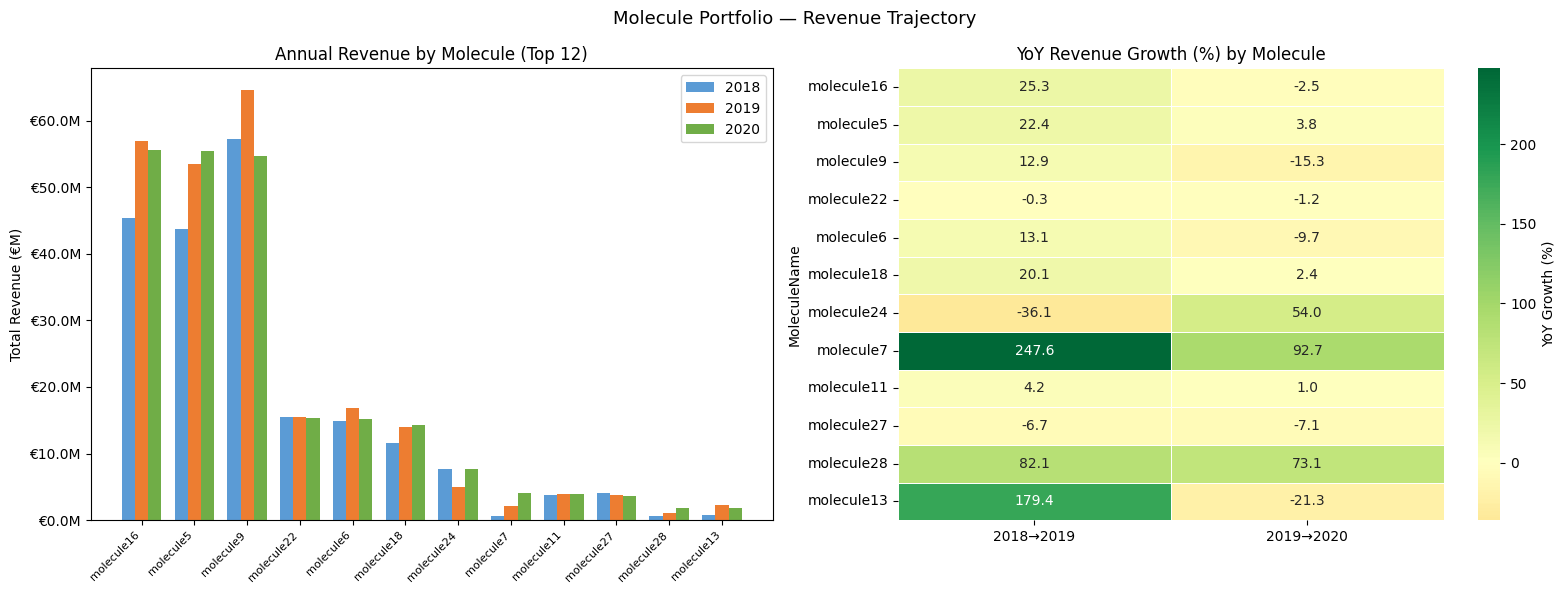

In [3]:
top_molecules = yoy.head(12).index.tolist()
plot_data = (df_full_years[df_full_years['MoleculeName'].isin(top_molecules)]
             .groupby(['year', 'MoleculeName'])['Value'].sum()
             .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: grouped bar chart
pivot = plot_data.pivot(index='MoleculeName', columns='year', values='Value').fillna(0)
pivot = pivot.loc[top_molecules]
x = np.arange(len(pivot))
w = 0.25
colors = ['#5b9bd5', '#ed7d31', '#70ad47']
for i, (year, color) in enumerate(zip([2018, 2019, 2020], colors)):
    axes[0].bar(x + i*w, pivot[year] / 1e6, width=w, label=str(year), color=color)
axes[0].set_xticks(x + w)
axes[0].set_xticklabels(pivot.index, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Total Revenue (€M)')
axes[0].set_title('Annual Revenue by Molecule (Top 12)')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('€%.1fM'))

# Right: YoY growth heatmap
growth_data = yoy.loc[top_molecules, ['growth_18_19', 'growth_19_20']].rename(
    columns={'growth_18_19': '2018→2019', 'growth_19_20': '2019→2020'})
sns.heatmap(growth_data, annot=True, fmt='.1f', center=0,
            cmap='RdYlGn', ax=axes[1], linewidths=0.5,
            cbar_kws={'label': 'YoY Growth (%)'})
axes[1].set_title('YoY Revenue Growth (%) by Molecule')
axes[1].set_xlabel('')

plt.suptitle('Molecule Portfolio — Revenue Trajectory', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/bi_yoy_growth.png', dpi=150, bbox_inches='tight')
plt.show()

## Price-per-Pack by Molecule

`Value / Packs` gives an implied price per unit sold. This varies widely across molecules because:
- Different drug classes have fundamentally different price points (specialty vs. generic)
- Higher-priced molecules generate disproportionate revenue on relatively low volume

Understanding this split matters for forecasting: a model that performs poorly on a low-volume but  
high-price molecule will have more business impact than the same error on a high-volume, low-price one.

In [ ]:
price_per_pack = (df.groupby('MoleculeName')
                   .apply(lambda g: pd.Series({
                       'total_value': g['Value'].sum(),
                       'total_packs': g['Packs'].sum(),
                       'median_price_per_pack': (g['Value'] / g['Packs']).median(),
                       'records': len(g)
                   }), include_groups=False)
                   .reset_index()
                   .sort_values('median_price_per_pack', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: price per pack bar chart
colors_price = ['#c62828' if p > price_per_pack['median_price_per_pack'].median() else '#1565c0'
                for p in price_per_pack['median_price_per_pack']]
axes[0].barh(price_per_pack['MoleculeName'], price_per_pack['median_price_per_pack'],
             color=colors_price, alpha=0.85)
axes[0].axvline(price_per_pack['median_price_per_pack'].median(),
                color='black', linestyle='--', linewidth=1, label='Portfolio median')
axes[0].set_xlabel('Median Price per Pack (€)')
axes[0].set_title('Implied Price per Pack by Molecule')
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_formatter(mticker.FormatStrFormatter('€%.0f'))

# Right: volume vs revenue scatter (bubble = price per pack)
axes[1].scatter(
    price_per_pack['total_packs'] / 1e6,
    price_per_pack['total_value'] / 1e6,
    s=price_per_pack['median_price_per_pack'] * 2,
    alpha=0.6, color='steelblue', edgecolors='white', linewidths=0.5
)
for _, row in price_per_pack.iterrows():
    axes[1].annotate(row['MoleculeName'],
                     (row['total_packs']/1e6, row['total_value']/1e6),
                     fontsize=7, alpha=0.8)
axes[1].set_xlabel('Total Packs (millions)')
axes[1].set_ylabel('Total Revenue (€M)')
axes[1].set_title('Volume vs Revenue\n(bubble size = median price per pack)')
axes[1].xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1fM'))
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('€%.1fM'))

plt.suptitle('Molecule Pricing Analysis', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/bi_price_per_pack.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 highest-priced molecules:")
print(price_per_pack[['MoleculeName','median_price_per_pack','total_value','total_packs']].head()
      .to_string(index=False))

## Market Concentration

A small number of SKUs typically account for the majority of pharmaceutical revenue — this is a  
well-known pattern in pharma markets. We quantify this with a **Lorenz curve** (revenue concentration  
curve): if revenue were equally distributed, the curve would follow the diagonal; the further it bows  
below the diagonal, the more concentrated revenue is in fewer products.

The **Gini coefficient** (area between the curve and the diagonal × 2) summarises concentration  
in a single number: 0 = perfectly equal, 1 = all revenue from one SKU.

This matters for forecasting: a high Gini coefficient means that forecast accuracy on a handful of  
top SKUs dominates overall portfolio-level accuracy.

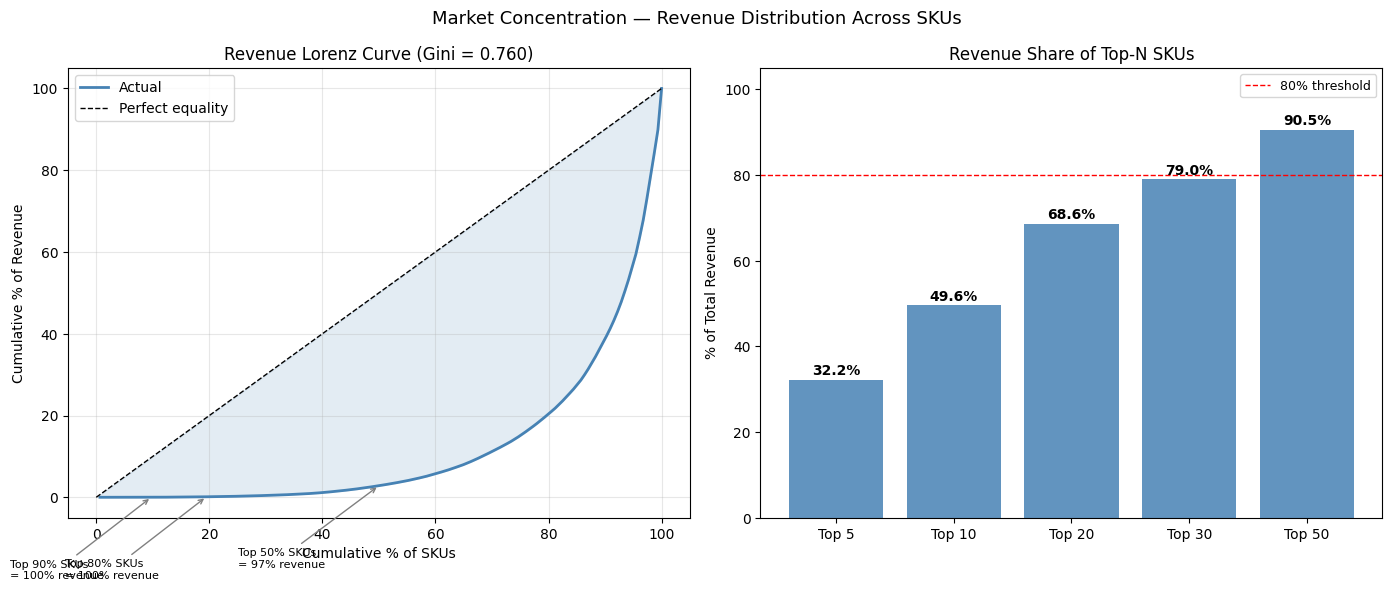

Gini coefficient: 0.760
  Top  5 SKUs account for 32.2% of total revenue
  Top 10 SKUs account for 49.6% of total revenue
  Top 20 SKUs account for 68.6% of total revenue
  Top 30 SKUs account for 79.0% of total revenue
  Top 50 SKUs account for 90.5% of total revenue


In [6]:
sku_revenue = df.groupby('ProductName')['Value'].sum().sort_values()
cumulative_skus    = np.arange(1, len(sku_revenue) + 1) / len(sku_revenue) * 100
cumulative_revenue = sku_revenue.cumsum() / sku_revenue.sum() * 100

# Gini coefficient
n = len(sku_revenue)
gini = (2 * np.sum(np.arange(1, n+1) * sku_revenue.values) /
        (n * sku_revenue.sum()) - (n+1) / n)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Lorenz curve
axes[0].plot(cumulative_skus, cumulative_revenue, color='steelblue', linewidth=2, label='Actual')
axes[0].plot([0, 100], [0, 100], 'k--', linewidth=1, label='Perfect equality')
axes[0].fill_between(cumulative_skus, cumulative_revenue, cumulative_skus, alpha=0.15, color='steelblue')
axes[0].set_xlabel('Cumulative % of SKUs')
axes[0].set_ylabel('Cumulative % of Revenue')
axes[0].set_title(f'Revenue Lorenz Curve (Gini = {gini:.3f})')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Annotate key thresholds
cum_rev_arr = cumulative_revenue.values
for pct_sku in [10, 20, 50]:
    idx = int(pct_sku / 100 * len(cumulative_skus)) - 1
    pct_rev = cum_rev_arr[idx]
    axes[0].annotate(f'Top {100-pct_sku}% SKUs\n= {100-pct_rev:.0f}% revenue',
                     xy=(cumulative_skus[idx], pct_rev),
                     xytext=(cumulative_skus[idx]-25, pct_rev-20),
                     fontsize=8, arrowprops=dict(arrowstyle='->', color='gray'))

# Right: top-N revenue share bar
thresholds = [5, 10, 20, 30, 50]
top_n_share = [(df.groupby('ProductName')['Value'].sum()
                 .sort_values(ascending=False).head(n).sum() /
                 df['Value'].sum() * 100) for n in thresholds]
axes[1].bar([f'Top {n}' for n in thresholds], top_n_share, color='steelblue', alpha=0.85)
for i, (x, y) in enumerate(zip(thresholds, top_n_share)):
    axes[1].text(i, y + 0.5, f'{y:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[1].axhline(80, color='red', linestyle='--', linewidth=1, label='80% threshold')
axes[1].set_ylabel('% of Total Revenue')
axes[1].set_title('Revenue Share of Top-N SKUs')
axes[1].set_ylim(0, 105)
axes[1].legend(fontsize=9)

plt.suptitle('Market Concentration — Revenue Distribution Across SKUs', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/bi_market_concentration.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Gini coefficient: {gini:.3f}")
for n, share in zip(thresholds, top_n_share):
    print(f"  Top {n:>2} SKUs account for {share:.1f}% of total revenue")


## Monthly Seasonality Heatmap

A calendar heatmap shows total portfolio revenue in each month/year cell.  
This makes seasonal peaks immediately visible — interviewers and stakeholders can read it at a glance  
without needing to interpret a line chart.

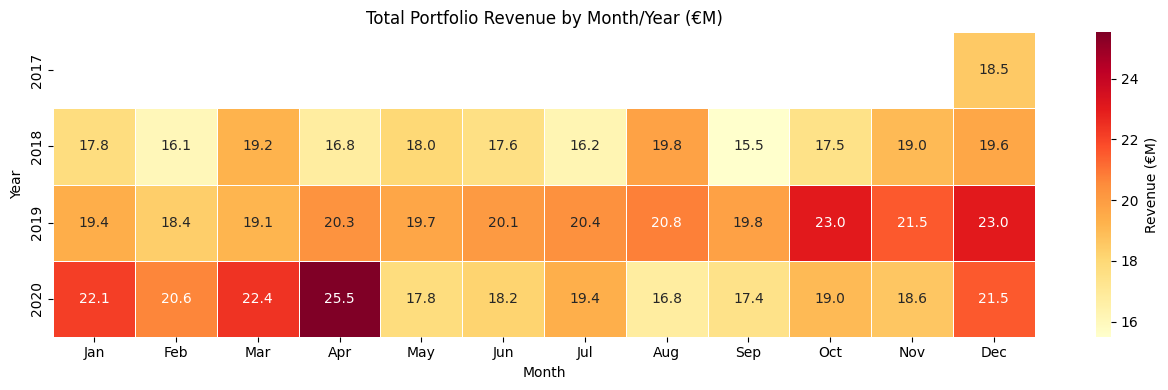

In [7]:
monthly_total = (df.groupby(['year', 'month'])['Value']
                  .sum()
                  .reset_index()
                  .pivot(index='year', columns='month', values='Value'))

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
monthly_total.columns = [month_labels[m-1] for m in monthly_total.columns]

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(monthly_total / 1e6, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Revenue (€M)'})
ax.set_title('Total Portfolio Revenue by Month/Year (€M)', fontsize=12)
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
plt.savefig('../outputs/bi_seasonality_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Business Insights

| Insight | Business implication |
|---|---|
| Revenue is highly concentrated (Gini > 0.5) | Forecast errors on top-10 SKUs dominate portfolio accuracy |
| Price per pack varies 10–100× across molecules | High-price molecules need higher absolute accuracy, not just lower % error |
| Some molecules show consistent YoY growth; others decline | Declining-trend products are harder to forecast — model may underpredict the drop |
| Seasonal peak is visible in Q4 (Oct–Dec) for most molecules | A model without seasonal features will systematically under-forecast Q4 |
| New market entrants (< 12 months history) exist in the portfolio | These cannot be reliably forecasted — a confidence flag in the output would be appropriate in production |

**Outputs saved to `outputs/`:**
- `bi_yoy_growth.png`
- `bi_price_per_pack.png`
- `bi_market_concentration.png`
- `bi_seasonality_heatmap.png`